<a href="https://colab.research.google.com/github/AkhilaSunesh/Epoch_Data_Science_Bootcamp/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 7
**Name:** Akhila Sunesh <br>
**Date:** 27nd July 2026 <br>
**Time:** 6:58pm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [3]:
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()


(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
df_model = df.drop('CustomerID', axis=1).copy()

le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])  # Female=0, Male=1
df_model.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [8]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df_model[features]
X.head()


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,7.284319e-01,6.656748e-01,8.851316e-01
max,2.235532e+00,2.917671e+00,1.894492e+00


### Elbow Method

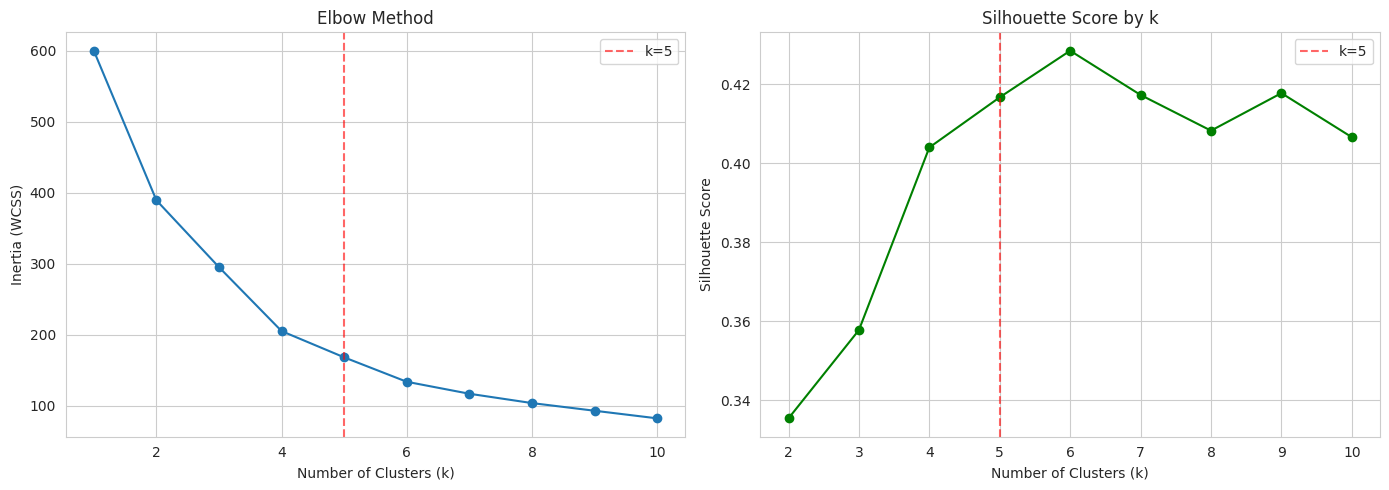

k=2: silhouette=0.3355
k=3: silhouette=0.3578
k=4: silhouette=0.4040
k=5: silhouette=0.4166
k=6: silhouette=0.4284
k=7: silhouette=0.4172
k=8: silhouette=0.4082
k=9: silhouette=0.4177
k=10: silhouette=0.4066


In [10]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Also compute inertia for k=1 for the elbow plot
km1 = KMeans(n_clusters=1, init='k-means++', n_init=10, random_state=42).fit(X_scaled)
inertia_full = [km1.inertia_] + inertias
k_full = [1] + list(K_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_full, inertia_full, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.6, label='k=5')
axes[0].legend()

axes[1].plot(list(K_range), silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.6, label='k=5')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=100)
plt.show()

for k, sc in zip(K_range, silhouette_scores):
    print(f"k={k}: silhouette={sc:.4f}")


**Observation:** The inertia curve bends noticeably around **k=5**, after which additional clusters yield diminishing reductions in WCSS. The silhouette score also peaks around k=5-6, confirming this is a well-separated choice. We proceed with **k=5**.

### Train the final K-Means model

In [11]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
print(f"Final silhouette score (k={optimal_k}): {silhouette_score(X_scaled, cluster_labels):.4f}")
df.head()


Final silhouette score (k=5): 0.4166


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [12]:
df['Cluster'].value_counts().sort_index()


,count
Cluster,
0,20
1,54
2,40
3,39
4,47


In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_var[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_var[1]*100:.2f}%")
print(f"Total variance explained by 2 components: {explained_var.sum()*100:.2f}%")


Variance explained by PC1: 44.27%
Variance explained by PC2: 33.31%
Total variance explained by 2 components: 77.57%


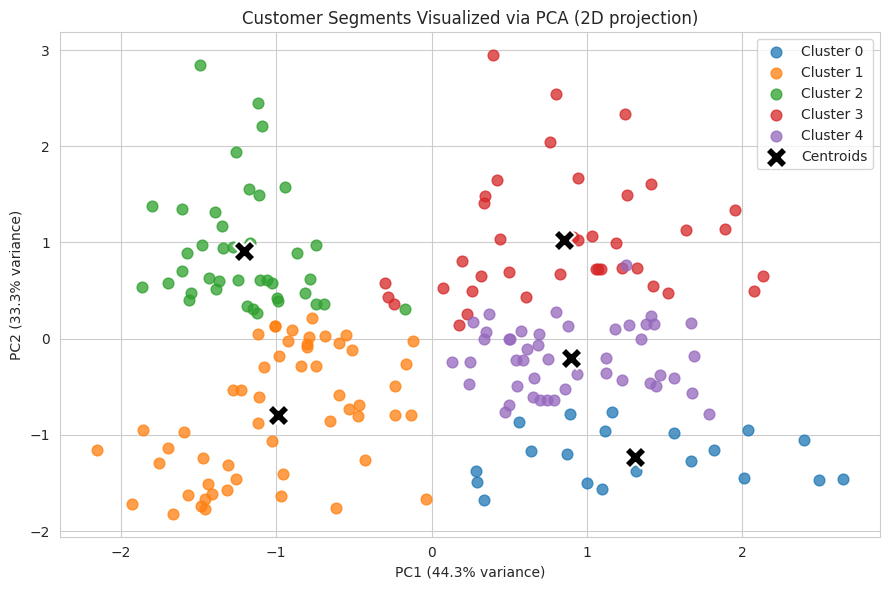

In [14]:
plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', optimal_k)

for cluster in range(optimal_k):
    mask = cluster_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}',
                s=60, alpha=0.75, color=palette[cluster])

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=250,
            c='black', edgecolor='white', linewidth=1.5, label='Centroids')

plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.title('Customer Segments Visualized via PCA (2D projection)')
plt.legend()
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=100)
plt.show()


In [15]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile['Female %'] = df.groupby('Cluster')['Gender'].apply(lambda s: (s == 'Female').mean() * 100).round(1)
cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Count,Female %
Cluster,,,,,
0,46.2,26.8,18.4,20,60.0
1,25.2,41.1,62.2,54,59.3
2,32.9,86.1,81.5,40,55.0
3,39.9,86.1,19.4,39,48.7
4,55.6,54.4,48.9,47,57.4


/tmp/ipykernel_767/3610324391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feat, ax=ax, palette='tab10')
/tmp/ipykernel_767/3610324391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feat, ax=ax, palette='tab10')
/tmp/ipykernel_767/3610324391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feat, ax=ax, palette='tab10')


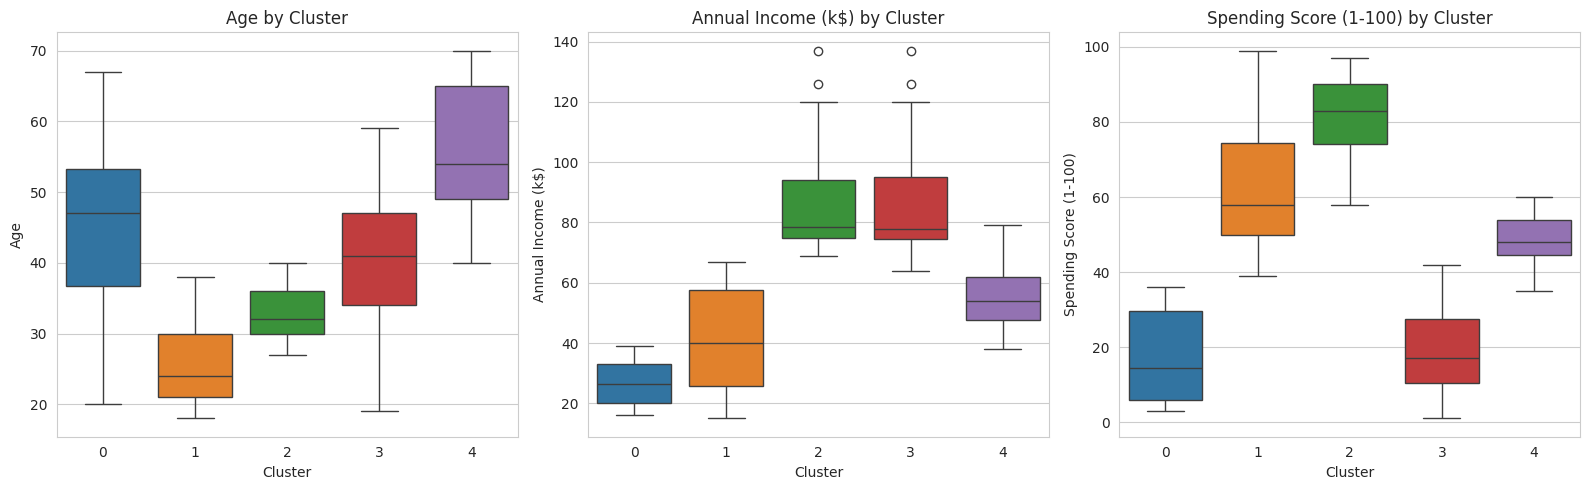

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(data=df, x='Cluster', y=feat, ax=ax, palette='tab10')
    ax.set_title(f'{feat} by Cluster')
plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=100)
plt.show()


### Assigning business names to clusters

Based on the average Age, Annual Income, and Spending Score of each cluster:

| Cluster | Profile | Business Name |
|---|---|---|
| 0 | Mid-to-high income, low spending score | **Careful Spenders** |
| 1 | Low income, low spending score | **Budget-Conscious Shoppers** |
| 2 | Mid income, mid spending score | **Average / Standard Customers** |
| 3 | High income, high spending score | **Premium Target Customers** |
| 4 | Low income, high spending score | **Impulsive Young Spenders** |

*(Exact numeric assignment of cluster IDs to names should be verified against the `cluster_profile` table output above, since K-Means cluster label order is not fixed across runs.)*

In [17]:
def name_cluster(row):
    income, spend, age = row['Annual Income (k$)'], row['Spending Score (1-100)'], row['Age']
    if income >= 70 and spend >= 60:
        return 'Premium Target Customers'
    elif income >= 70 and spend < 60:
        return 'Careful Spenders'
    elif income < 45 and spend >= 60:
        return 'Impulsive Young Spenders'
    elif income < 45 and spend < 45:
        return 'Budget-Conscious Shoppers'
    else:
        return 'Average / Standard Customers'

cluster_profile['Segment Name'] = cluster_profile.apply(name_cluster, axis=1)
cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Count,Female %,Segment Name
Cluster,,,,,,
0,46.2,26.8,18.4,20,60.0,Budget-Conscious Shoppers
1,25.2,41.1,62.2,54,59.3,Impulsive Young Spenders
2,32.9,86.1,81.5,40,55.0,Premium Target Customers
3,39.9,86.1,19.4,39,48.7,Careful Spenders
4,55.6,54.4,48.9,47,57.4,Average / Standard Customers


Based on the cluster profiles above, here are the key insights and recommended strategies:

**1. Premium Target Customers** (high income, high spending score)
- Insight: These customers spend generously relative to their high income — the most valuable segment for revenue.
- Strategy: Offer loyalty programs, VIP previews, and premium/exclusive product lines. Prioritize personalized service and retention campaigns.

**2. Careful Spenders** (high income, low spending score)
- Insight: Financially capable but not currently engaged — an untapped opportunity.
- Strategy: Investigate why spending is low (product mix? brand perception?). Use targeted promotions, quality-focused messaging, or personalized recommendations to convert them into higher spenders.

**3. Impulsive Young Spenders** (low income, high spending score)
- Insight: Spend beyond what their income might suggest, likely younger, trend-driven customers.
- Strategy: Flash sales, trendy/affordable product lines, buy-now-pay-later options, and social-media-driven marketing.

**4. Budget-Conscious Shoppers** (low income, low spending score)
- Insight: Price-sensitive, low engagement segment.
- Strategy: Value bundles, discounts, and essential-goods promotions. Avoid heavy investment in premium marketing for this group.

**5. Average / Standard Customers** (mid income, mid spending score)
- Insight: The "typical" mall customer, moderate in both dimensions.
- Strategy: General seasonal campaigns and broad-based promotions; a good testing ground for new offers before rolling out mall-wide.

### Overall Conclusion
Age, Annual Income, and Spending Score together produce well-separated, business-interpretable clusters. The optimal number of segments is **5**, confirmed by both the Elbow Method and Silhouette Score. This segmentation allows the mall's marketing team to move from a one-size-fits-all approach to targeted strategies for each customer type, potentially improving marketing ROI and customer retention.
